# Results Analysis

Interactive error analysis for benchmark outputs. The notebook filters and samples existing result CSVs, then calls the model inference scripts as Python functions on the selected decoded samples and plots predictions inline.

In [308]:
from __future__ import annotations

import argparse
import importlib
import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import to_rgb
from matplotlib.patches import Rectangle
from skimage import measure

ROOT = Path.cwd()
if not (ROOT / "benchmarks").exists():
    ROOT = Path.cwd().parents[0]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from datasets.loader import add_dataset_args, build_decoder_from_args
from datasets.common import ensure_three_channels, normalize_to_uint8

RESULTS_DIR = ROOT / "results"

## Helpers

In [309]:
def result_dir(model: str, dataset: str, protocol: str = "gt_bbox") -> Path:
    return RESULTS_DIR / f"{model}_{protocol}_{dataset}"


def load_results(model: str, dataset: str, protocol: str = "gt_bbox") -> tuple[pd.DataFrame, dict]:
    folder = result_dir(model, dataset, protocol)
    metrics_path = folder / "per_sample_metrics.csv"
    summary_path = folder / "summary.json"
    if not metrics_path.exists():
        raise FileNotFoundError(metrics_path)
    df = pd.read_csv(metrics_path)
    summary = json.loads(summary_path.read_text()) if summary_path.exists() else {}
    return df, summary


def sample_by_bins(
    df: pd.DataFrame,
    metric: str,
    bins: list[tuple[str, float | None, float | None]],
    n: int,
    seed: int,
) -> dict[str, pd.DataFrame]:
    rng = np.random.default_rng(seed)
    sampled = {}
    for label, low, high in bins:
        mask = pd.Series(True, index=df.index)
        if low is not None:
            mask &= df[metric] >= low
        if high is not None:
            mask &= df[metric] < high
        group = df.loc[mask].copy()
        if len(group) > n:
            group = group.iloc[rng.choice(len(group), size=n, replace=False)].copy()
        sampled[label] = group.reset_index(drop=True)
    return sampled


def repo_path(path: str | Path | None) -> str:
    if path in (None, ""):
        return ""
    path = Path(path)
    return str(path if path.is_absolute() else ROOT / path)


def decoder_args(dataset: str, dataset_root: str = "") -> argparse.Namespace:
    parser = argparse.ArgumentParser()
    add_dataset_args(parser, include_camus=True)
    args = parser.parse_args([])
    args.dataset = dataset
    args.dataset_root = repo_path(dataset_root)
    args.no_auto_download = True
    return args


def load_decoder(dataset: str, summary: dict | None = None):
    summary = summary or {}
    return build_decoder_from_args(decoder_args(dataset, dataset_root=summary.get("dataset_root")))


def load_samples(decoder, sample_ids: list[str]):
    samples = []
    missing = []
    for sample_id in sample_ids:
        try:
            samples.append(decoder.load_sample(sample_id))
        except Exception:
            missing.append(sample_id)
    if not missing:
        return samples

    found = {sample.sample_id: sample for sample in samples}
    missing_set = set(missing)
    for sample in decoder.iter_samples(max_samples=None):
        if sample.sample_id in missing_set:
            found[sample.sample_id] = sample
            missing_set.remove(sample.sample_id)
        if not missing_set:
            break
    if missing_set:
        raise KeyError(f"Could not load sample_id(s): {sorted(missing_set)}")
    return [found[sample_id] for sample_id in sample_ids]


def run_model_on_samples(model: str, samples, summary: dict | None = None, **kwargs):
    summary = summary or {}
    if model == "ultrasam":
        module = importlib.import_module("benchmarks.ultrasam_inference")
        defaults = {
            "checkpoint": summary.get("checkpoint", "work_dir/UltraSam/UltraSam.pth"),
            "checkpoint_url": summary.get("checkpoint_url", module.DEFAULT_ULTRASAM_CHECKPOINT_URL),
            "ultrasam_dir": summary.get("ultrasam_dir"),
            "config": summary.get("config", module.DEFAULT_ULTRASAM_CONFIG),
            "box_padding": int(summary.get("box_padding", 0)),
            "bbox_mode": summary.get("bbox_mode", "union"),
            "batch_size": int(summary.get("batch_size", 4)),
        }
        defaults.update(kwargs)
        return module.run_ultrasam_on_samples(samples, **defaults)
    if model == "medsam":
        module = importlib.import_module("benchmarks.medsam_inference")
        allowed = {
            "device", "checkpoint", "checkpoint_repo_id", "checkpoint_filename",
            "checkpoint_revision", "no_auto_download_checkpoint", "box_padding",
            "bbox_mode", "bbox_jitter_prob", "bbox_jitter_fraction",
        }
        return module.run_medsam_on_samples(
            samples, **{key: value for key, value in kwargs.items() if key in allowed}
        )
    if model == "samus":
        module = importlib.import_module("benchmarks.samus_inference")
        allowed = {
            "device", "batch_size", "num_workers", "checkpoint", "sam_ckpt",
            "no_auto_download_checkpoint", "checkpoint_file_id", "box_padding",
            "bbox_mode", "encoder_input_size", "low_image_size", "vit_name",
        }
        return module.run_samus_on_samples(
            samples, **{key: value for key, value in kwargs.items() if key in allowed}
        )
    raise ValueError(f"Unsupported model: {model}")

## Load Existing Results

In [310]:
model = "ultrasam"
dataset = "busbra"
protocol = "gt_bbox"

# Bounding-box prompt mode for the re-run inference:
#   "union"      -> one box around the full target mask
#   "individual" -> one box per connected component (>15 px)
bbox_mode = "individual"

df, summary = load_results(model, dataset, protocol)
df[["sample_id", "dice", "hd95", "iou"]].describe()

,dice,hd95,iou
count,1875.000000,1875.000000,1875.000000
mean,0.938857,7.340962,0.886038
std,0.028199,5.230107,0.048181
min,0.735395,1.414214,0.581522
25%,0.926466,4.000000,0.863005
50%,0.945195,5.830952,0.896085
75%,0.958467,8.944272,0.920246
max,0.988409,44.054377,0.977083


## Filter And Randomly Sample

In [311]:
dice_bins = [
    (">94", 0.94, None),
    ("92-94", 0.92, 0.94),
    ("90-92", 0.90, 0.92),
    ("88-90", 0.88, 0.90),
    ("86-88", 0.86, 0.88),
    ("84-86", 0.84, 0.86),
    ("82-84", 0.82, 0.844),
    ("<82", None, 0.82),
]
samples_per_bin = 5
random_seed = None

sampled_rows = sample_by_bins(df, "dice", dice_bins, samples_per_bin, random_seed)
for label, rows in sampled_rows.items():
    print(f"Dice: {label}: {len(rows)} selected")
    # display(rows[["sample_id", "dice", "hd95", "iou"]])

Dice: >94: 5 selected
Dice: 92-94: 5 selected
Dice: 90-92: 5 selected
Dice: 88-90: 5 selected
Dice: 86-88: 5 selected
Dice: 84-86: 5 selected
Dice: 82-84: 5 selected
Dice: <82: 5 selected


## Load Selected Samples And Re-Run Inference on them

In [312]:
device = summary.get("device", "cuda:0")
batch_size = int(summary.get("batch_size", 4))
num_workers = 0

ultrasam_dir = Path(repo_path(summary.get("ultrasam_dir"))) if summary.get("ultrasam_dir") else Path("")
if model == "ultrasam" and not ultrasam_dir.exists():
    ultrasam_dir = ROOT / "UltraSam"
ultrasam_checkpoint = Path(repo_path(summary.get("checkpoint"))) if summary.get("checkpoint") else Path("")
if model == "ultrasam" and not ultrasam_checkpoint.exists():
    ultrasam_checkpoint = ROOT / "UltraSam" / "weights" / "UltraSam.pth"
ultrasam_config = summary.get("config")
if model == "ultrasam" and ultrasam_config and not Path(ultrasam_config).exists():
    ultrasam_config = "configs/UltraSAM/UltraSAM_full/UltraSAM_box_refine.py"

decoder = load_decoder(dataset, summary)
results_by_bin = {}
csv_metrics_by_bin = {}
for label, rows in sampled_rows.items():
    sample_ids = rows["sample_id"].astype(str).tolist()
    csv_metrics_by_bin[label] = rows.assign(sample_id=sample_ids).set_index("sample_id").to_dict("index")
    samples = load_samples(decoder, sample_ids)
    results_by_bin[label] = run_model_on_samples(
        model,
        samples,
        summary,
        device=device,
        batch_size=batch_size,
        num_workers=num_workers,
        bbox_mode=bbox_mode,
        ultrasam_dir=ultrasam_dir,
        checkpoint=ultrasam_checkpoint,
        config=ultrasam_config,
    )
    print(f"{label}: inferred {len(results_by_bin[label])} sample(s)")

Loads checkpoint by local backend from path: /home/ultrai/UltrAi/monai_us_segmentor/us_multi_anatomy_seg/work_dir/UltraSam/UltraSam.pth
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
>94: inferred 5 sample(s)
Loads checkpoint by local backend from path: /home/ultrai/UltrAi/monai_us_segmentor/us_multi_anatomy_seg/work_dir/UltraSam/UltraSam.pth
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
92-94: inferred 5 sample(s)
Loads checkpoint by local backend from path: /home/ultrai/UltrAi/monai_us_segmentor/us_multi_anatomy_seg/work_dir/UltraSam/UltraSam.pth
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
90-92: inferred 5 sample(s)
Loads checkpoint by local backend from path: /home/ultrai/UltrAi/monai_us_segmentor/us_multi_anatomy_seg/work_dir/UltraSam/UltraSam.pth
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
88-90: inferred 5 sample(s)
Loads checkpoi

## Visualize

In [313]:
def _draw_gt_outline(axis, gt_mask: np.ndarray, color: str, linewidth: float) -> None:
    for contour in measure.find_contours(gt_mask.astype(float), 0.5):
        axis.plot(contour[:, 1], contour[:, 0], color=color, linewidth=linewidth)


def _draw_bboxes(axis, bbox, color: str, linewidth: float) -> None:
    boxes = np.asarray(bbox).reshape(-1, 4)
    for x0, y0, x1, y1 in boxes:
        axis.add_patch(
            Rectangle(
                (float(x0), float(y0)),
                float(x1 - x0 + 1),
                float(y1 - y0 + 1),
                edgecolor=color,
                facecolor=(0, 0, 0, 0),
                linewidth=linewidth,
            )
        )


def _bbox_union(bbox: np.ndarray) -> tuple[float, float, float, float] | None:
    boxes = np.asarray(bbox, dtype=float).reshape(-1, 4)
    if boxes.size == 0:
        return None
    return (
        float(np.min(boxes[:, 0])),
        float(np.min(boxes[:, 1])),
        float(np.max(boxes[:, 2])),
        float(np.max(boxes[:, 3])),
    )


def _crop_bounds_from_bbox_for_inset(
    bbox: np.ndarray,
    image_shape: tuple[int, ...],
    *,
    inset_width_fraction: float = 0.40,
    inset_height_fraction: float = 0.30,
    target_width_fraction: float = 0.85,
) -> tuple[int, int, int, int] | None:
    union = _bbox_union(bbox)
    if union is None:
        return None

    height, width = image_shape[:2]
    x0, y0, x1, y1 = union
    target_width = max(x1 - x0 + 1.0, 1.0)
    target_height = max(y1 - y0 + 1.0, 1.0)
    target_center_x = (x0 + x1) / 2.0
    target_center_y = (y0 + y1) / 2.0

    inset_aspect = (width * inset_width_fraction) / max(height * inset_height_fraction, 1e-6)
    crop_width = target_width / target_width_fraction
    crop_width = max(crop_width, (target_height / target_width_fraction) * inset_aspect)
    crop_height = crop_width / inset_aspect

    crop_width = min(max(crop_width, 1.0), float(width))
    crop_height = min(max(crop_height, 1.0), float(height))
    crop_x0 = int(round(target_center_x - crop_width / 2.0))
    crop_y0 = int(round(target_center_y - crop_height / 2.0))
    crop_x0 = min(max(crop_x0, 0), max(width - int(round(crop_width)), 0))
    crop_y0 = min(max(crop_y0, 0), max(height - int(round(crop_height)), 0))
    crop_x1 = min(crop_x0 + int(round(crop_width)), width)
    crop_y1 = min(crop_y0 + int(round(crop_height)), height)
    return crop_x0, crop_y0, crop_x1, crop_y1


def _image_flush_inset_bounds(
    image_shape: tuple[int, ...],
    *,
    width_fraction: float = 0.40,
    height_fraction: float = 0.30,
) -> list[float]:
    height, width = image_shape[:2]
    inset_width = width * width_fraction
    inset_height = height * height_fraction
    return [width - 0.5 - inset_width, height - 0.5 - inset_height, inset_width, inset_height]


def _crop_relative_bboxes(bbox: np.ndarray, crop_x0: int, crop_y0: int) -> np.ndarray:
    boxes = np.asarray(bbox, dtype=float).reshape(-1, 4).copy()
    boxes[:, [0, 2]] -= crop_x0
    boxes[:, [1, 3]] -= crop_y0
    return boxes


def _draw_roblus_target_inset(
    axis,
    image: np.ndarray,
    bbox: np.ndarray,
    *,
    gt_mask: np.ndarray | None = None,
    pred_mask: np.ndarray | None = None,
    draw_annotations: bool = False,
    inset_width_fraction: float = 0.60,
    inset_height_fraction: float = 0.40,
    target_width_fraction: float = 0.85,
    pred_color: str = "lightskyblue",
    pred_alpha: float = 0.45,
    gt_outline_color: str = "white",
    gt_outline_width: float = 1.1,
    bbox_color: str = "yellow",
    bbox_linewidth: float = 0.8,
) -> None:
    crop_bounds = _crop_bounds_from_bbox_for_inset(
        bbox,
        image.shape,
        inset_width_fraction=inset_width_fraction,
        inset_height_fraction=inset_height_fraction,
        target_width_fraction=target_width_fraction,
    )
    if crop_bounds is None:
        return

    crop_x0, crop_y0, crop_x1, crop_y1 = crop_bounds
    inset_axis = axis.inset_axes(
        _image_flush_inset_bounds(
            image.shape,
            width_fraction=inset_width_fraction,
            height_fraction=inset_height_fraction,
        ),
        transform=axis.transData,
    )
    inset_axis.imshow(image[crop_y0:crop_y1, crop_x0:crop_x1], cmap="gray")

    if pred_mask is not None:
        pred_crop = pred_mask[crop_y0:crop_y1, crop_x0:crop_x1]
        pred_rgb = np.array(to_rgb(pred_color))
        overlay = np.zeros((*pred_crop.shape, 4), dtype=float)
        overlay[..., :3] = pred_rgb
        overlay[..., 3] = (pred_crop > 0) * pred_alpha
        inset_axis.imshow(overlay)

    if draw_annotations:
        if gt_mask is not None:
            gt_crop = gt_mask[crop_y0:crop_y1, crop_x0:crop_x1]
            _draw_gt_outline(inset_axis, gt_crop, gt_outline_color, gt_outline_width * 1.8)
        _draw_bboxes(
            inset_axis,
            _crop_relative_bboxes(bbox, crop_x0, crop_y0),
            bbox_color,
            bbox_linewidth * 1.8,
        )
    inset_axis.set_xticks([])
    inset_axis.set_yticks([])
    for spine in inset_axis.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("#ffb347")
        spine.set_linewidth(1.0)
        spine.set_linestyle("dotted")


In [314]:
def plot_bin_rows(
    results_by_bin: dict[str, list],
    *,
    csv_metrics_by_bin: dict[str, dict[str, dict]] | None = None,
    pred_color: str = "lightskyblue",
    pred_alpha: float = 0.45,
    gt_outline_color: str = "white",
    gt_outline_width: float = 1.1,
    bbox_color: str = "yellow",
    bbox_linewidth: float = 0.8,
    panel_width: float = 3.6,
    image_row_height: float = 2.85,
    overlay_row_height: float = 3.15,
    pair_gap_height: float = 0.05,
    show_roblus_target_inset: bool = True,
    target_inset_width_fraction: float = 0.60,
    target_inset_height_fraction: float = 0.50,
    target_inset_target_width_fraction: float = 0.85,
) -> None:
    csv_metrics_by_bin = csv_metrics_by_bin or {}
    max_cols = max((len(values) for values in results_by_bin.values()), default=1)
    bin_count = max(len(results_by_bin), 1)
    plot_rows = bin_count * 3 - 1
    height_ratios = []
    for bin_idx in range(bin_count):
        height_ratios.extend([image_row_height, overlay_row_height])
        if bin_idx < bin_count - 1:
            height_ratios.append(pair_gap_height)

    fig, axes = plt.subplots(
        plot_rows,
        max_cols,
        figsize=(panel_width * max_cols, sum(height_ratios)),
        gridspec_kw={"height_ratios": height_ratios},
        squeeze=False,
    )
    fig.subplots_adjust(hspace=0.08)
    pred_rgb = np.array(to_rgb(pred_color))
    for bin_idx, (bin_label, results) in enumerate(results_by_bin.items()):
        image_row = bin_idx * 3
        overlay_row = image_row + 1
        spacer_row = image_row + 2
        if spacer_row < plot_rows:
            for spacer_ax in axes[spacer_row, :]:
                spacer_ax.axis("off")

        for col_idx in range(max_cols):
            image_ax = axes[image_row, col_idx]
            overlay_ax = axes[overlay_row, col_idx]
            image_ax.axis("off")
            overlay_ax.axis("off")
            if col_idx >= len(results):
                continue

            result = results[col_idx]
            image = ensure_three_channels(normalize_to_uint8(result.image))
            is_roblus = str(getattr(result.sample, "dataset", "")).lower() == "roblus"

            image_ax.imshow(image, cmap="gray")
            image_ax.set_title(str(result.sample.sample_id), fontsize=8)
            if show_roblus_target_inset and is_roblus:
                _draw_roblus_target_inset(
                    image_ax,
                    image,
                    result.bbox,
                    draw_annotations=False,
                    inset_width_fraction=target_inset_width_fraction,
                    inset_height_fraction=target_inset_height_fraction,
                    target_width_fraction=target_inset_target_width_fraction,
                    pred_color=pred_color,
                    pred_alpha=pred_alpha,
                    gt_outline_color=gt_outline_color,
                    gt_outline_width=gt_outline_width,
                    bbox_color=bbox_color,
                    bbox_linewidth=bbox_linewidth,
                )

            overlay_ax.imshow(image, cmap="gray")
            overlay = np.zeros((*result.pred_mask.shape, 4), dtype=float)
            overlay[..., :3] = pred_rgb
            overlay[..., 3] = (result.pred_mask > 0) * pred_alpha
            overlay_ax.imshow(overlay)
            _draw_gt_outline(overlay_ax, result.gt_mask, gt_outline_color, gt_outline_width)
            _draw_bboxes(overlay_ax, result.bbox, bbox_color, bbox_linewidth)
            if show_roblus_target_inset and is_roblus:
                _draw_roblus_target_inset(
                    overlay_ax,
                    image,
                    result.bbox,
                    gt_mask=result.gt_mask,
                    pred_mask=result.pred_mask,
                    draw_annotations=True,
                    inset_width_fraction=target_inset_width_fraction,
                    inset_height_fraction=target_inset_height_fraction,
                    target_width_fraction=target_inset_target_width_fraction,
                    pred_color=pred_color,
                    pred_alpha=pred_alpha,
                    gt_outline_color=gt_outline_color,
                    gt_outline_width=gt_outline_width,
                    bbox_color=bbox_color,
                    bbox_linewidth=bbox_linewidth,
                )
            rerun_dice = result.metrics.get("dice", math.nan)
            rerun_hd95 = result.metrics.get("hd95", math.nan)
            csv_metrics = csv_metrics_by_bin.get(bin_label, {}).get(str(result.sample.sample_id), {})
            csv_dice = csv_metrics.get("dice", math.nan)
            csv_hd95 = csv_metrics.get("hd95", math.nan)
            overlay_ax.set_title(
                f"CSV Dice {csv_dice:.3f} | rerun {rerun_dice:.3f}\n"
                f"CSV HD95 {csv_hd95:.1f} | rerun {rerun_hd95:.1f}",
                fontsize=8,
            )

        axes[image_row, 0].text(
            -0.02,
            0.5,
            f"{bin_label}\n(n={len(results)})",
            transform=axes[image_row, 0].transAxes,
            ha="right",
            va="center",
            fontsize=9,
            fontweight="bold",
        )
        axes[overlay_row, 0].text(
            -0.02,
            0.5,
            "overlay",
            transform=axes[overlay_row, 0].transAxes,
            ha="right",
            va="center",
            fontsize=8,
        )
    plt.tight_layout()
    plt.show()


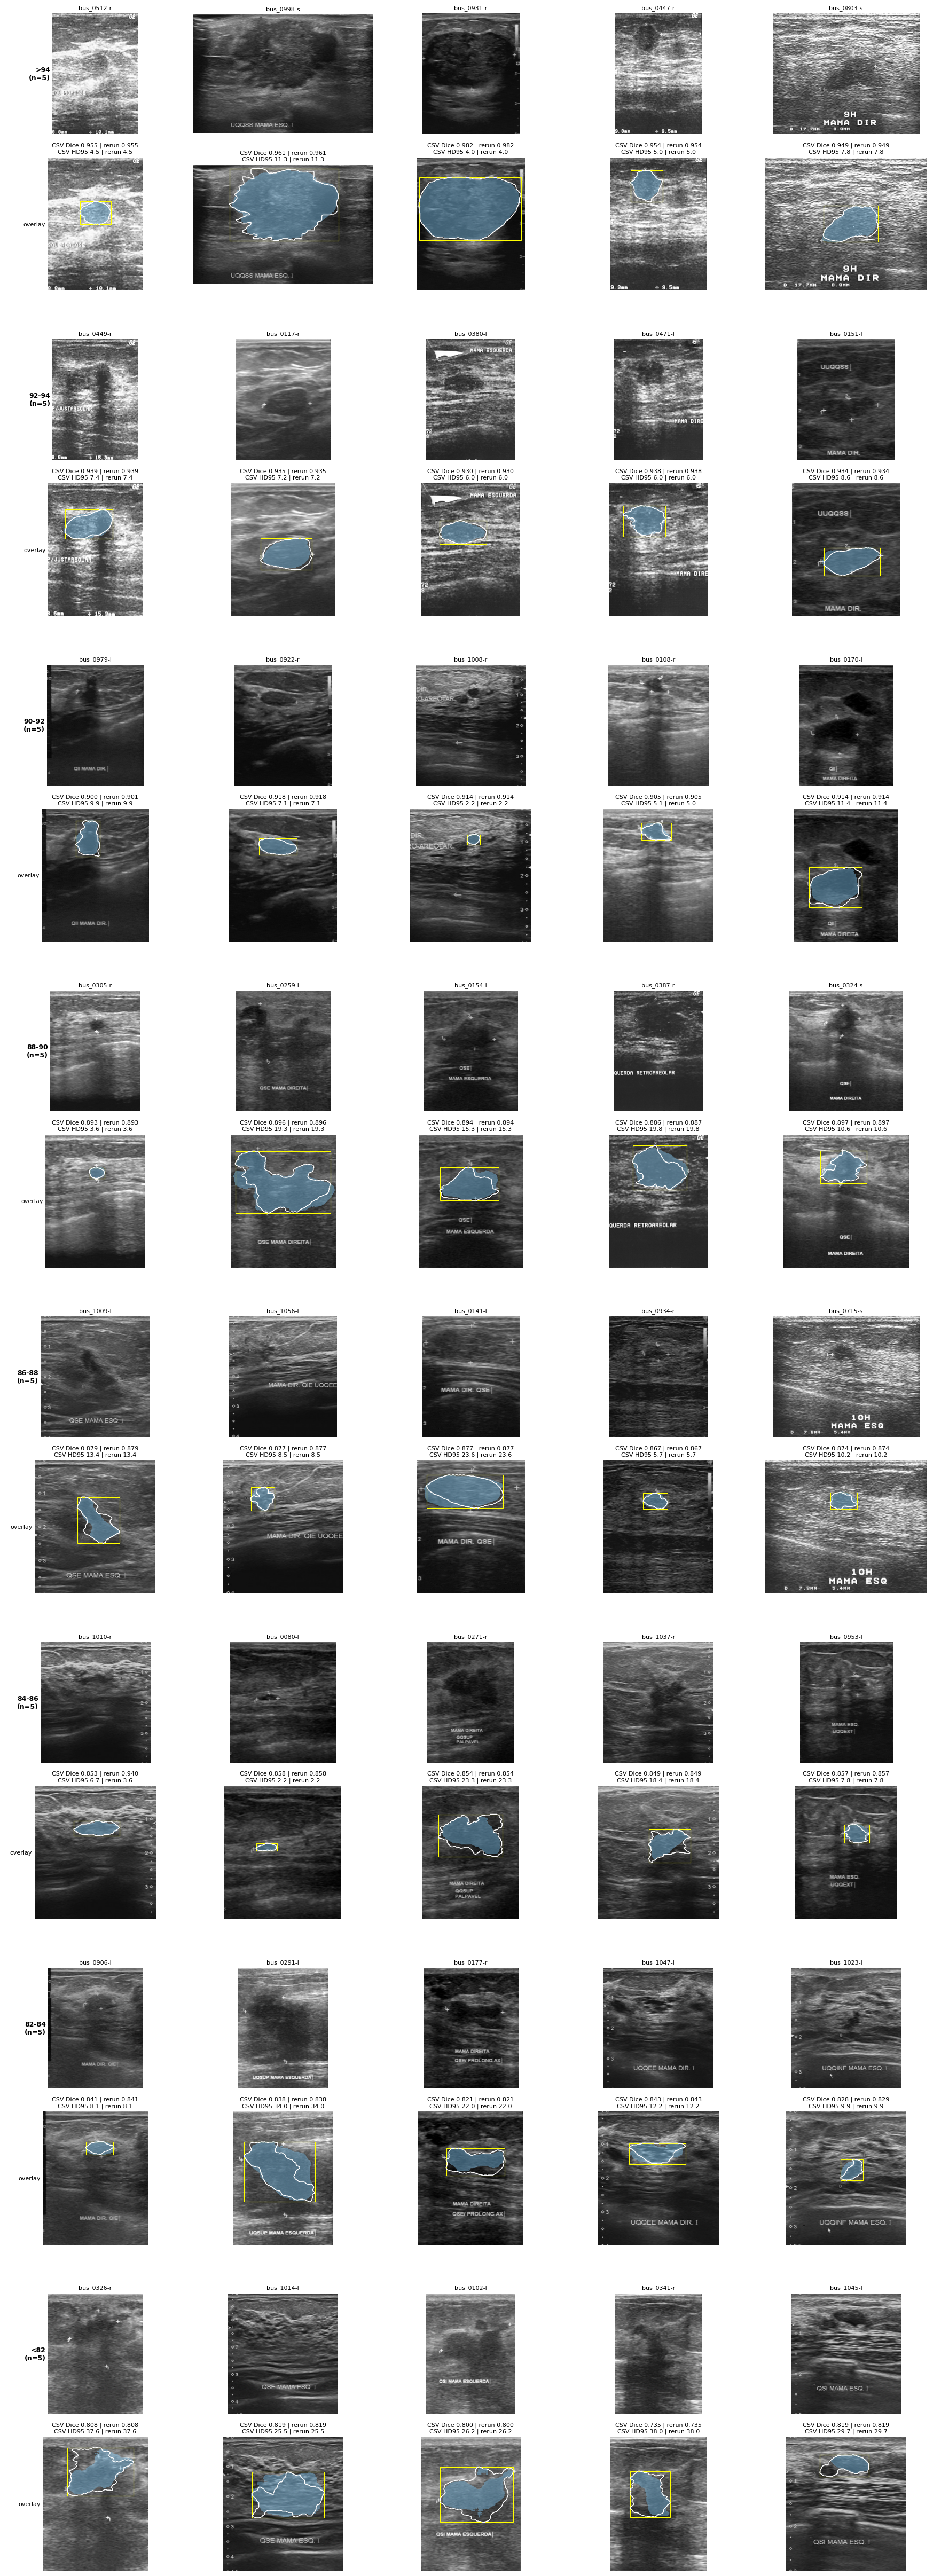

In [315]:
pred_color = "lightskyblue"
pred_alpha = 0.45
gt_outline_color = "white"
gt_outline_width = 1.1
bbox_color = "yellow"
bbox_linewidth = 0.8

plot_bin_rows(
    results_by_bin,
    csv_metrics_by_bin=csv_metrics_by_bin,
    pred_color=pred_color,
    pred_alpha=pred_alpha,
    gt_outline_color=gt_outline_color,
    gt_outline_width=gt_outline_width,
    bbox_color=bbox_color,
    bbox_linewidth=bbox_linewidth,
)